# Notebook 5 — Policy Gradients: REINFORCE, Baselines, Actor-Critic & GAE

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. **Policy Gradients (VPG, REINFORCE, baselines, GAE)** ← *you are here*
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. RLOO & Critic-Free Methods (RLVR)
9. GRPO & the DeepSeek-R1 line of work
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

Still **only `numpy` and `matplotlib`**. We reuse the from-scratch `MLP` and
`Adam` from notebook 4, copied into this notebook so it runs on its own.

### Recap

Notebook 4 made value-based RL scale: a neural network $Q_w(s,a)$, trained by
semi-gradient TD with experience replay and a target network, learned CartPole
from raw state numbers. We ended on a problem, though. The policy DQN produces
is an *afterthought* — "take the argmax of $Q$" — and for LLMs that's backwards.
A pretrained LLM already **is** a policy: a network that outputs a probability
distribution over the next token. We don't want to replace it with a Q-table.
We want to **adjust the distribution it already has**, so that good responses
become more likely and bad ones less likely.

That's this notebook's job. Instead of learning values and deriving a policy,
we'll parametrize the policy $\pi_\theta(a\mid s)$ directly and do gradient
ascent on the quantity we actually care about, expected return:

$$
J(\theta) = \mathbb E_{\tau \sim \pi_\theta}\big[ R(\tau) \big].
$$

The entire difficulty — and the one clever trick at the heart of every LLM RL
algorithm (PPO, RLOO, GRPO, and the RL step inside RLCD in notebook 11) — is
computing $\nabla_\theta J$ when $\theta$ changes *which samples we get*.

### What this notebook covers

- Why optimize the policy directly, and the **softmax policy**.
- The **log-derivative trick** (score-function estimator), derived on a
  **bandit** (notebook 1's "one prompt, one completion, one reward" view) and
  checked numerically against the exact gradient.
- The key intuition: **policy gradient = supervised learning on your own
  samples, weighted by reward**.
- **REINFORCE** for full trajectories: the environment dynamics drop out of
  the gradient, and "causality" gives reward-to-go. We use it to "fine-tune"
  notebook 1's `TinySequenceEnv` token generator.
- **Variance** is the enemy: **baselines** (proved unbiased) and the
  **leave-one-out** baseline — the seed of RLOO and GRPO.
- **Actor-critic**: a learned $V_\phi$ as the baseline, trained by TD
  (notebook 3), with the TD error as a one-step advantage.
- **Generalized Advantage Estimation (GAE)**: derived from notebook 3's n-step
  returns as a single bias–variance dial $\lambda$.
- REINFORCE vs. baseline vs. GAE on CartPole, with the gradient variance
  measured directly.
- The failure that motivates notebook 6: **one step too large and the policy
  collapses — permanently**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)       # subtract max for numerical stability
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

# ---------------- From notebook 4, unchanged ----------------
class MLP:
    def __init__(self, sizes, activation="tanh", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}
            if i > 0:
                dh = G @ self.params[i]["W"].T
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)
        return grads

    def predict(self, x):
        return self.forward(x)[0]


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                p[k] -= self.lr * (m[k] / (1 - self.b1 ** self.t)) / (np.sqrt(v[k] / (1 - self.b2 ** self.t)) + self.eps)


class CartPole:
    '''CartPole-v1 dynamics in pure numpy (notebook 4).'''
    def __init__(self, max_steps=500, seed=None):
        self.gravity, self.m_cart, self.m_pole, self.half_len = 9.8, 1.0, 0.1, 0.5
        self.force_mag, self.dt = 10.0, 0.02
        self.x_limit, self.theta_limit = 2.4, 12 * 2 * np.pi / 360
        self.max_steps = max_steps
        self.rng = np.random.default_rng(seed)

    def reset(self):
        self.state = self.rng.uniform(-0.05, 0.05, size=4); self.t = 0
        return self.state.copy()

    def step(self, action):
        x, x_dot, th, th_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        cos_t, sin_t = np.cos(th), np.sin(th)
        total_m = self.m_cart + self.m_pole; pml = self.m_pole * self.half_len
        temp = (force + pml * th_dot ** 2 * sin_t) / total_m
        th_acc = (self.gravity * sin_t - cos_t * temp) / (self.half_len * (4.0 / 3.0 - self.m_pole * cos_t ** 2 / total_m))
        x_acc = temp - pml * th_acc * cos_t / total_m
        x, x_dot = x + self.dt * x_dot, x_dot + self.dt * x_acc
        th, th_dot = th + self.dt * th_dot, th_dot + self.dt * th_acc
        self.state = np.array([x, x_dot, th, th_dot]); self.t += 1
        terminated = bool(abs(x) > self.x_limit or abs(th) > self.theta_limit)
        return self.state.copy(), 1.0, terminated, self.t >= self.max_steps


class TinySequenceEnv:
    '''Notebook 1's miniature "LLM": vocabulary {A,B,C}, length 3, reward 1 only for "ABC".'''
    ACTIONS = ["A", "B", "C"]
    def __init__(self, target=("A", "B", "C"), max_len=3):
        self.target, self.max_len, self.start = target, max_len, tuple()
    def is_terminal(self, s):
        return len(s) >= self.max_len
    def step(self, s, a):
        s_next = s + (a,)
        done = self.is_terminal(s_next)
        return s_next, (1.0 if (done and s_next == self.target) else 0.0), done

## 1. Why optimize the policy directly?

Three reasons, all of which point straight at LLMs:

1. **It's the thing we actually want.** DQN learns $Q$ very accurately in
   regions that don't matter, then takes an argmax. Policy methods spend their
   capacity on *behavior*.
2. **Stochastic policies come for free.** A policy that outputs a
   distribution can express "70% left, 30% right." That's useful for
   exploration, necessary in games where predictability gets exploited, and
   exactly what a language model is: $\pi_\theta(\text{token} \mid \text{context})$.
3. **Big (or continuous) action spaces are fine.** We never need
   $\max_a Q(s,a)$ over 100,000 tokens. We only need to *sample* from
   $\pi_\theta$ and evaluate $\log \pi_\theta$ of what we sampled.

The standard parametrization for discrete actions is the **softmax** over
scores ("logits") $z_a$:

$$
\pi_\theta(a \mid s) = \frac{e^{z_a(s;\theta)}}{\sum_{b} e^{z_b(s;\theta)}} .
$$

The logits can come from a table (one vector per state), a linear model, an
MLP, or a 70-billion-parameter transformer — the math below doesn't care.

## 2. The log-derivative trick, on a bandit

Start with the simplest case, which is also notebook 1's **bandit view of an
LLM**: one state (the prompt), one action (the whole completion), one reward.
There are $K$ arms, arm $a$ pays $r(a)$ on average, and the policy is a softmax
over a logit vector $\theta \in \mathbb R^K$:

$$
J(\theta) = \mathbb E_{a\sim\pi_\theta}[r(a)] = \sum_a \pi_\theta(a)\, r(a).
$$

### The problem

We want $\nabla_\theta J$. Here we *could* write it out because the sum has
only $K$ terms. For an LLM, the "sum over all actions" is a sum over all
possible completions — astronomically many. We can only **sample**
completions and see their rewards. And the difficulty is that $\theta$ appears
in the *distribution we sample from*, not inside the function we evaluate. We
can't just "differentiate the samples."

### The trick

Differentiate anyway, and use one identity: $\nabla_\theta \pi = \pi\, \nabla_\theta \log \pi$
(because $\nabla \log \pi = \nabla\pi / \pi$).

$$
\nabla_\theta J = \sum_a \nabla_\theta \pi_\theta(a)\; r(a)
= \sum_a \pi_\theta(a)\, \nabla_\theta \log \pi_\theta(a)\; r(a)
= \boxed{\;\mathbb E_{a\sim\pi_\theta}\big[\nabla_\theta \log \pi_\theta(a)\; r(a)\big]\;}
$$

The sum became an **expectation under the policy**, so we can estimate it by
sampling: draw $a_1..a_N \sim \pi_\theta$ and average $\nabla\log\pi_\theta(a_i)\,r(a_i)$.
No need to know $r$ for actions we didn't try, and no need to differentiate $r$
at all — $r$ can be a black box (a unit-test runner, a math checker, a reward
model).

### The score of a softmax

For the softmax, $\log\pi_\theta(a) = \theta_a - \log\sum_b e^{\theta_b}$, so

$$
\frac{\partial \log \pi_\theta(a)}{\partial \theta_j} = \mathbb 1[j=a] - \pi_\theta(j)
\qquad\Longleftrightarrow\qquad
\nabla_\theta \log\pi_\theta(a) = \text{onehot}(a) - \pi_\theta .
$$

Read it: "raise the logit of the action you took, lower everything else in
proportion to its current probability." Multiplied by $r(a)$, the update
reinforces actions in proportion to their reward. Hence the name
**REINFORCE**.

Let's verify the estimator numerically against the exact gradient
$\partial J/\partial\theta_j = \pi_j\,(r_j - J)$ (derive it yourself from the
sum — it's a good exercise).

In [2]:
true_means = np.array([0.2, 0.5, 1.0, 0.1, 0.6])      # arm 2 is best
K = len(true_means)
reward_noise = 0.5

def pull(a, rng):
    return true_means[a] + reward_noise * rng.normal(size=np.shape(a))

def exact_grad(theta):
    p = softmax(theta)
    J = p @ true_means
    return p * (true_means - J)

def score_function_grad(theta, n_samples, rng, baseline=0.0):
    p = softmax(theta)
    a = rng.choice(K, size=n_samples, p=p)
    r = pull(a, rng)
    scores = np.eye(K)[a] - p                    # grad log pi(a) = onehot(a) - p, per sample
    return ((r - baseline)[:, None] * scores).mean(axis=0)

rng = np.random.default_rng(0)
theta0 = np.array([0.5, 0.0, -0.5, 0.3, 0.0])
g_true = exact_grad(theta0)
print("exact gradient        :", np.round(g_true, 4))
for n in [10, 100, 10_000, 1_000_000]:
    g_hat = score_function_grad(theta0, n, rng)
    print(f"estimate, N={n:>9,d} :", np.round(g_hat, 4), f"  |error| = {np.linalg.norm(g_hat - g_true):.4f}")
assert np.linalg.norm(score_function_grad(theta0, 1_000_000, rng) - g_true) < 5e-3

exact gradient        : [-0.0551  0.0201  0.0663 -0.0692  0.0379]
estimate, N=       10 : [-0.0929 -0.0169  0.1104 -0.1192  0.1187]   |error| = 0.1173
estimate, N=      100 : [-0.0708  0.0337  0.0535 -0.0951  0.0787]   |error| = 0.0541
estimate, N=   10,000 : [-0.0515  0.0219  0.0692 -0.0764  0.0368]   |error| = 0.0088
estimate, N=1,000,000 : [-0.0549  0.0205  0.0658 -0.0696  0.0382]   |error| = 0.0008


The sampled estimate converges to the exact gradient, with error shrinking like
$1/\sqrt N$. The log-derivative trick is correct. Now we use it: stochastic
gradient **ascent** on $J$, drawing a small batch of pulls per step.

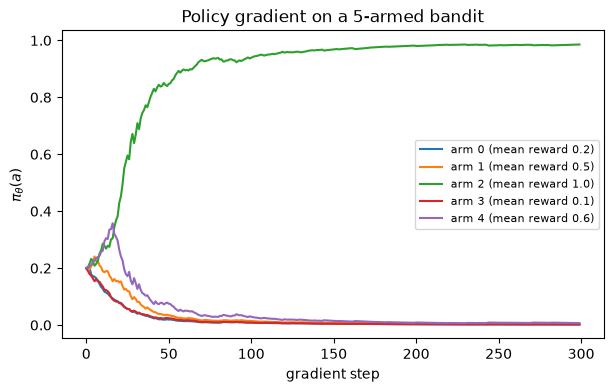

In [3]:
def bandit_pg(lr=0.5, batch=8, n_steps=300, baseline_kind="none", reward_shift=0.0, seed=0):
    rng = np.random.default_rng(seed)
    theta = np.zeros(K)
    probs_hist = []
    for _ in range(n_steps):
        p = softmax(theta)
        probs_hist.append(p)
        a = rng.choice(K, size=batch, p=p)
        r = pull(a, rng) + reward_shift
        if baseline_kind == "none":
            b = 0.0
        elif baseline_kind == "loo":     # leave-one-out: mean of the OTHER samples' rewards
            b = (r.sum() - r) / (batch - 1)
        scores = np.eye(K)[a] - p
        theta += lr * ((r - b)[:, None] * scores).mean(axis=0)
    return np.array(probs_hist)

probs = bandit_pg()
fig, ax = plt.subplots(figsize=(7, 4))
for k in range(K):
    ax.plot(probs[:, k], label=f"arm {k} (mean reward {true_means[k]})")
ax.set_xlabel("gradient step"); ax.set_ylabel("$\\pi_\\theta(a)$")
ax.set_title("Policy gradient on a 5-armed bandit"); ax.legend(fontsize=8); plt.show()

Probability mass flows to the best arm, learned only from sampled pulls and
noisy rewards.

### The single most important intuition in this notebook

Compare two losses for a softmax model and a chosen action $a$:

| | Loss (to *minimize*) | Gradient w.r.t. logits |
|---|---|---|
| **Supervised learning** (cross-entropy on label $a^\star$) | $-\log\pi_\theta(a^\star)$ | $-(\text{onehot}(a^\star) - \pi_\theta)$ |
| **Policy gradient** (sampled $a$, reward $r$) | $-\,r \cdot \log\pi_\theta(a)$ | $-\,r\,(\text{onehot}(a) - \pi_\theta)$ |

**Policy gradient is supervised learning in which the labels are the model's
own samples, and each example is weighted by its reward.** High reward: "do
more of what you just did." Zero reward: ignore it. Negative reward: "do less
of what you just did."

For an LLM this is completely literal. Take the SFT (supervised fine-tuning)
cross-entropy code, feed it the model's *own generations* instead of
human-written targets, and multiply each sequence's loss by its reward — that's
the core of REINFORCE-style LLM RL. Everything else in notebooks 5–9 is about
making that weighting less noisy and the steps safer.

## 3. REINFORCE for full trajectories

Now let the agent take several actions per episode (e.g. several tokens). A
trajectory $\tau = (s_0, a_0, r_1, s_1, a_1, \dots)$ has probability

$$
P_\theta(\tau) = p(s_0) \prod_{t} \pi_\theta(a_t \mid s_t)\, P(s_{t+1}\mid s_t, a_t).
$$

Apply the same trick to $J(\theta) = \mathbb E_\tau[R(\tau)]$:
$\nabla J = \mathbb E_\tau[\nabla_\theta \log P_\theta(\tau)\, R(\tau)]$. And look at what the
log does to the product:

$$
\nabla_\theta \log P_\theta(\tau) = \underbrace{\nabla_\theta \log p(s_0)}_{=0} + \sum_t \nabla_\theta\log\pi_\theta(a_t\mid s_t) + \sum_t \underbrace{\nabla_\theta \log P(s_{t+1}\mid s_t,a_t)}_{=0}.
$$

**The environment dynamics vanish from the gradient**, because they don't
depend on $\theta$. We never need to know or model $P$. This is what makes
policy gradients *model-free*. So

$$
\nabla_\theta J = \mathbb E_\tau\Big[\sum_t \nabla_\theta \log\pi_\theta(a_t\mid s_t)\; R(\tau)\Big].
$$

### Causality: reward-to-go

That formula credits action $a_t$ with the *whole* episode's reward, including
rewards received **before** $a_t$ was taken. An action can't affect the past,
so those terms are pure noise. (Formally, $\mathbb E[\nabla\log\pi(a_t|s_t)\, r_{t'}] = 0$
for $t' \le t$, by the same argument as the baseline proof in Section 4.)
Dropping them gives the lower-variance **REINFORCE** estimator:

$$
\boxed{\;\nabla_\theta J = \mathbb E_\tau\Big[\sum_t \nabla_\theta\log\pi_\theta(a_t\mid s_t)\; G_t\Big], \qquad G_t = \sum_{k\ge 0}\gamma^k r_{t+k+1}\;}
$$

— with $G_t$ the return from notebook 1. (Strictly, the discounted version
$\gamma^t$-weights each term too. Like essentially every practical
implementation, we drop that factor.)

### "Fine-tuning" our tiny language model

Back to notebook 1's `TinySequenceEnv`: the vocabulary is {A, B, C}, sequences
have length 3, and reward is 1 only for "ABC". Our "language model" is a table
of logits, one 3-vector per prefix (13 prefixes: empty, A, B, C, AA, …),
starting uniform — so initially $P(\text{"ABC"}) = 1/27$. Each gradient step we
**generate a batch of sequences, score them, and apply REINFORCE**. That is,
structurally, what RL fine-tuning of an LLM does.

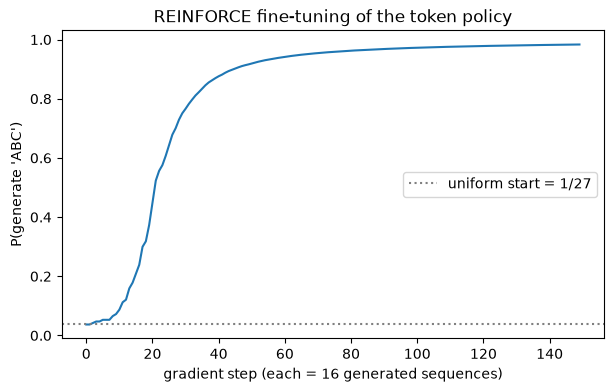

10 generations after training: ['ABC', 'ABC', 'ABC', 'ABC', 'ABC', 'ABC', 'ABC', 'ABC', 'ABC', 'ABC']
learned next-token distribution after prefix 'A': {'A': np.float64(0.003), 'B': np.float64(0.994), 'C': np.float64(0.003)}
learned next-token distribution after prefix 'C': {'A': np.float64(0.333), 'B': np.float64(0.333), 'C': np.float64(0.333)}


In [4]:
seq_env = TinySequenceEnv()
VOCAB = TinySequenceEnv.ACTIONS
ALL_PREFIXES = [()] + [(a,) for a in VOCAB] + [(a, b) for a in VOCAB for b in VOCAB]

def sequence_prob(logits, seq):
    '''Exact probability of generating `seq` -- a product of per-token softmax probabilities.'''
    p, prefix = 1.0, ()
    for tok in seq:
        p *= softmax(logits[prefix])[VOCAB.index(tok)]
        prefix = prefix + (tok,)
    return p

def generate(logits, rng):
    s, traj = seq_env.start, []
    while not seq_env.is_terminal(s):
        a_idx = rng.choice(3, p=softmax(logits[s]))
        s_next, r, done = seq_env.step(s, VOCAB[a_idx])
        traj.append((s, a_idx, r))
        s = s_next
    return traj

def reinforce_sequences(lr=1.0, batch=16, n_steps=150, baseline="none", seed=0):
    rng = np.random.default_rng(seed)
    logits = {p: np.zeros(3) for p in ALL_PREFIXES}
    p_target = []
    for _ in range(n_steps):
        p_target.append(sequence_prob(logits, seq_env.target))
        trajs = [generate(logits, rng) for _ in range(batch)]
        # reward-to-go for every token; gamma = 1 (finite episodes)
        rtg = [np.cumsum([r for (_, _, r) in tr][::-1])[::-1] for tr in trajs]
        seq_rewards = np.array([g[0] for g in rtg])
        grads = {p: np.zeros(3) for p in ALL_PREFIXES}
        for i, (tr, g) in enumerate(zip(trajs, rtg)):
            b = 0.0
            if baseline == "loo":                          # leave-one-out over the batch
                b = (seq_rewards.sum() - seq_rewards[i]) / (batch - 1)
            for t, (s, a_idx, _) in enumerate(tr):
                grads[s] += (g[t] - b) * (np.eye(3)[a_idx] - softmax(logits[s]))
        for p in ALL_PREFIXES:
            logits[p] += lr * grads[p] / batch
    return np.array(p_target), logits

p_hist, learned_logits = reinforce_sequences()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_hist)
ax.axhline(1 / 27, color="gray", ls=":", label="uniform start = 1/27")
ax.set_xlabel("gradient step (each = 16 generated sequences)")
ax.set_ylabel("P(generate 'ABC')"); ax.set_title("REINFORCE fine-tuning of the token policy")
ax.legend(); plt.show()

rng = np.random.default_rng(1)
samples = ["".join(VOCAB[a] for (_, a, _) in generate(learned_logits, rng)) for _ in range(10)]
print("10 generations after training:", samples)
print("learned next-token distribution after prefix 'A':", dict(zip(VOCAB, np.round(softmax(learned_logits[('A',)]), 3))))
print("learned next-token distribution after prefix 'C':", dict(zip(VOCAB, np.round(softmax(learned_logits[('C',)]), 3))))

$P(\text{"ABC"})$ climbs from $1/27$ to nearly 1. Look at the last line,
though: after prefix "C" the distribution **did not move at all** — still
exactly uniform. Two reasons, and both matter for LLMs:

- Every sequence starting with "C" gets reward 0, and with no baseline a
  zero-reward sample contributes a gradient of exactly $0 \cdot \nabla\log\pi = 0$.
  REINFORCE only learns from *differences in reward* among the things it
  actually sampled.
- Once the root learned to avoid "C", the policy stopped generating those
  prefixes, so they would get no signal at all anymore, baseline or not.

RL only improves the model **where the model actually goes**. That's true of LLMs too, and it's one reason the starting (SFT) model
matters so much: RL sharpens behavior the model already produces sometimes. It
rarely conjures behavior the model never samples.

There's a second, subtler point. With reward only for an exact match, a batch
in which nobody generated "ABC" gives a gradient of **exactly zero** — nothing
to learn from. At $P = 1/27$ and batch size 16, that happens about 55% of the
time early on. This **sparse-reward / exploration** problem is why LLM RL
starts from a good SFT model, and why methods like GRPO sample *many*
completions per prompt.

## 4. Variance: the real enemy, and baselines

The REINFORCE estimator is unbiased but **noisy**. Here's a thought
experiment that exposes the problem. Add $+10$ to every reward in the bandit.
The *best arm* doesn't change, and neither does the true gradient: $\pi_j(r_j - J)$
contains $r_j - J$, in which the shift cancels. But the *estimator*
$r(a)\,(\text{onehot}(a) - \pi)$ now multiplies every sample by a number around
11 instead of around 1. Every sampled action gets pushed **up**, hard, even
the bad ones. Only the tiny differences between those big pushes carry
information. The expected update is unchanged. Its variance explodes.

### Baselines: subtract something that doesn't depend on the action

For any $b$ that does **not depend on the sampled action $a$**:

$$
\mathbb E_{a\sim\pi}\big[\nabla\log\pi_\theta(a)\; b\big]
= b\sum_a \pi_\theta(a)\,\frac{\nabla\pi_\theta(a)}{\pi_\theta(a)}
= b\,\nabla_\theta \underbrace{\sum_a \pi_\theta(a)}_{=1} = 0 .
$$

So $\mathbb E[\nabla\log\pi\,(r - b)] = \mathbb E[\nabla\log\pi\, r]$: **subtracting a
baseline never changes the expected gradient, but it can massively reduce the
variance.** A good choice is $b \approx \mathbb E[r]$ = "how good is it *on
average* here?", so that $r - b$ measures *better or worse than usual*. That
is an **advantage** (notebook 1: $A = Q - V$), and it's why every modern
algorithm talks about advantages rather than rewards.

### Baselines you can use without learning anything: the group

In a batch of $K$ samples for the same state (the same prompt), use the other
samples' average as the baseline for sample $i$:

$$
b_i = \frac{1}{K-1}\sum_{j\ne i} r_j \qquad\text{(leave-one-out)}.
$$

It doesn't depend on $a_i$ (samples are independent), so it's exactly
unbiased. This one line is the heart of **RLOO** (notebook 8). **GRPO**
(notebook 9) uses the full group mean including sample $i$ (plus division by
the group's standard deviation). That introduces a small bias, which we'll
examine there.

Let's measure the variance of the gradient estimate directly, on the shifted
bandit.

In [5]:
def grad_variance(baseline_kind, reward_shift, n_repeats=4000, batch=8, seed=0):
    rng = np.random.default_rng(seed)
    p = softmax(theta0)
    grads = []
    for _ in range(n_repeats):
        a = rng.choice(K, size=batch, p=p)
        r = pull(a, rng) + reward_shift
        if baseline_kind == "none":
            b = 0.0
        elif baseline_kind == "true_mean":
            b = p @ true_means + reward_shift        # an oracle: the exact E[r]
        elif baseline_kind == "loo":
            b = (r.sum() - r) / (batch - 1)
        grads.append(((r - b)[:, None] * (np.eye(K)[a] - p)).mean(axis=0))
    grads = np.array(grads)
    bias = np.linalg.norm(grads.mean(0) - exact_grad(theta0))
    return bias, grads.var(axis=0).sum()

print(f"{'reward shift':>12} | {'baseline':>10} | {'|mean - exact grad|':>20} | {'total variance':>14}")
for shift in [0.0, 10.0]:
    for kind in ["none", "true_mean", "loo"]:
        bias, var = grad_variance(kind, shift)
        print(f"{shift:>12} | {kind:>10} | {bias:>20.4f} | {var:>14.4f}")

reward shift |   baseline |  |mean - exact grad| | total variance
         0.0 |       none |               0.0033 |         0.0482
         0.0 |  true_mean |               0.0037 |         0.0308


         0.0 |        loo |               0.0035 |         0.0361
        10.0 |       none |               0.0515 |        10.5041
        10.0 |  true_mean |               0.0037 |         0.0308


        10.0 |        loo |               0.0035 |         0.0361


Read the table row by row:

- All three estimators are **unbiased**: the mean matches the exact gradient
  up to sampling noise. (The shifted, no-baseline row looks further off only
  *because* of its huge variance: with 4000 repeats, its standard error is
  about $\sqrt{10.5/4000} \approx 0.05$ — exactly the size of the gap.)
- Without a baseline, shifting rewards by $+10$ multiplies the variance by
  **more than $200\times$** — a number that means nothing ("+10 for every
  action") drowns out the signal.
- With either baseline the shift is **irrelevant**: the variance is the same
  at shift 0 and shift 10. The leave-one-out baseline gets close to the oracle
  without knowing anything in advance.

What that does to *learning*:

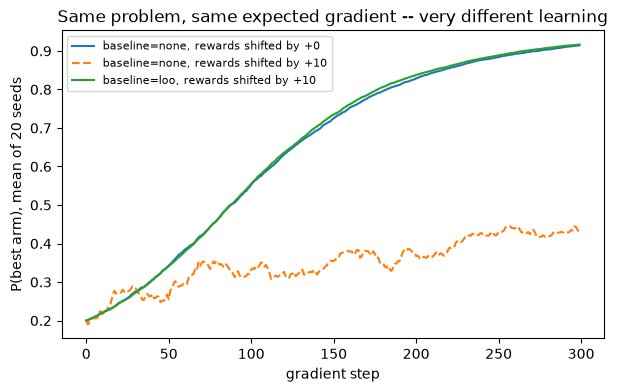

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for kind, shift, style in [("none", 0, "-"), ("none", 10, "--"), ("loo", 10, "-")]:
    runs = np.array([bandit_pg(lr=0.1, baseline_kind=kind, reward_shift=shift, seed=s)[:, 2] for s in range(20)])
    ax.plot(runs.mean(0), style, label=f"baseline={kind}, rewards shifted by +{shift}")
ax.set_xlabel("gradient step"); ax.set_ylabel("P(best arm), mean of 20 seeds")
ax.set_title("Same problem, same expected gradient -- very different learning")
ax.legend(fontsize=8); plt.show()

The dashed curve is the same problem, with the same expected gradient, yet it
learns at a fraction of the speed. The leave-one-out baseline (green) makes it
exactly as fast as the unshifted problem: it makes the algorithm **invariant to
the reward's offset**. That property matters enormously for LLMs, where reward
models output numbers on an arbitrary scale.

## 5. Actor-critic: learn the baseline

In a multi-step problem the best baseline for action $a_t$ is the expected
return from state $s_t$ — that is, $V^\pi(s_t)$. We don't know it, but we know
how to *learn* it: notebooks 3–4 are all about estimating $V$ from experience.
So we train two networks:

- the **actor** $\pi_\theta(a\mid s)$, updated by the policy gradient, and
- the **critic** $V_\phi(s)$, updated by regression (notebook 4's
  semi-gradient update, `.detach()` on the target and all).

The critic enters the actor's update through the **advantage estimate**
$\hat A_t$, and there are two natural choices, which should look familiar from
notebook 3:

| | Advantage estimate $\hat A_t$ | Bias | Variance |
|---|---|---|---|
| REINFORCE + baseline | $G_t - V_\phi(s_t)$ (full MC return) | none | high (sum of many random rewards) |
| one-step actor-critic | $\delta_t = r_{t+1} + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$ (TD error) | yes, if $V_\phi$ is wrong | low (one random reward) |

The TD error really is an advantage estimate. Since
$\mathbb E[r_{t+1} + \gamma V^\pi(s_{t+1}) \mid s_t, a_t] = Q^\pi(s_t,a_t)$, we get
$\mathbb E[\delta_t\mid s_t,a_t] = Q^\pi(s_t,a_t) - V^\pi(s_t) = A^\pi(s_t,a_t)$ when the
critic is exact.

This is exactly notebook 3's Monte Carlo vs. TD trade-off, now applied to
advantages. And just as n-step TD interpolated between MC and TD(0), we can
interpolate here, which brings us to GAE.

## 6. Generalized Advantage Estimation (GAE), derived

Define the **n-step advantage estimate**: take $n$ real rewards, then
bootstrap with the critic.

$$
\hat A^{(n)}_t = r_{t+1} + \gamma r_{t+2} + \dots + \gamma^{n-1}r_{t+n} + \gamma^n V(s_{t+n}) - V(s_t).
$$

$n = 1$ is the TD error. $n = \infty$ is $G_t - V(s_t)$. Now a neat identity:
**every n-step advantage is a discounted sum of one-step TD errors**, because
the intermediate $V$ terms telescope:

$$
\sum_{k=0}^{n-1} \gamma^k \delta_{t+k}
= \sum_{k=0}^{n-1} \gamma^k\big(r_{t+k+1} + \gamma V(s_{t+k+1}) - V(s_{t+k})\big)
= \sum_{k=0}^{n-1}\gamma^k r_{t+k+1} + \gamma^n V(s_{t+n}) - V(s_t) = \hat A^{(n)}_t .
$$

Rather than pick one $n$, GAE (Schulman et al., 2016) takes an exponentially
weighted average of *all* of them, with weights $(1-\lambda)\lambda^{n-1}$ (which
sum to 1). Substitute the telescoped form and collect the coefficient of each
$\delta_{t+k}$. It appears in every $\hat A^{(n)}$ with $n > k$, so its total
weight is $(1-\lambda)\sum_{n>k}\lambda^{n-1}\gamma^k = \gamma^k \lambda^k$:

$$
\boxed{\;\hat A^{\text{GAE}(\gamma,\lambda)}_t = \sum_{k\ge 0} (\gamma\lambda)^k\,\delta_{t+k}
\qquad\Longleftrightarrow\qquad
\hat A_t = \delta_t + \gamma\lambda\,\hat A_{t+1}\;}
$$

The right-hand recursion computes it in one backward pass. And $\lambda$ is a
single dial:

- $\lambda = 0$: $\hat A_t = \delta_t$ — the one-step TD advantage (low variance, biased).
- $\lambda = 1$: $\hat A_t = \sum_k \gamma^k\delta_{t+k} = G_t - V(s_t)$ — the MC advantage (unbiased, high variance).
- In practice, $\lambda \approx 0.95$.

### Episode boundaries: the details that make or break it

A batch of experience is a long stream containing many episodes. Two rules,
inherited from notebook 4's terminated/truncated distinction:

1. If $s_{t+1}$ is **terminated**, the future is worth 0: $\delta_t = r_{t+1} - V(s_t)$.
2. At **any** episode boundary (terminated, truncated, or the end of the
   batch cutting an episode in half), the recursion must **stop**: $\hat A_t$
   must not absorb TD errors from the *next* episode. But if the episode was
   only truncated or cut, we still bootstrap: $\delta_t$ uses $\gamma V(s_{t+1})$.

`compute_gae` implements both, and then we assert the $\lambda = 0$ and $\lambda = 1$
identities on random data containing all three kinds of boundary.

In [7]:
def compute_gae(rewards, values, next_values, terminated, episode_end, gamma, lam):
    '''
    rewards[t]     : r_{t+1}
    values[t]      : V(s_t)
    next_values[t] : V(s_{t+1})    (the true next state, even if the episode then reset)
    terminated[t]  : 1 if s_{t+1} is a real terminal state  -> no bootstrap
    episode_end[t] : 1 if the stream breaks after t (terminated, truncated, or batch cut)
    returns (advantages, returns = advantages + values  <- the critic's regression target)
    '''
    T = len(rewards)
    adv = np.zeros(T)
    running = 0.0
    for t in reversed(range(T)):
        delta = rewards[t] + gamma * next_values[t] * (1.0 - terminated[t]) - values[t]
        running = delta + gamma * lam * (1.0 - episode_end[t]) * running
        adv[t] = running
    return adv, adv + values

# ---- Test on a random stream with all three kinds of boundary ----
rng = np.random.default_rng(0)
T, gamma = 40, 0.9
r = rng.normal(size=T); v = rng.normal(size=T); v_next = rng.normal(size=T)
term = np.zeros(T); end = np.zeros(T)
term[9] = end[9] = 1        # a real termination
end[24] = 1                 # a truncation (time limit): end, but bootstrap
end[T - 1] = 1              # the batch cut at the end: end, but bootstrap
# within an episode the next state's value is the next entry's value:
for t in range(T - 1):
    if not end[t]:
        v_next[t] = v[t + 1]

adv0, _ = compute_gae(r, v, v_next, term, end, gamma, lam=0.0)
td_errors = r + gamma * v_next * (1 - term) - v
assert np.allclose(adv0, td_errors), "lambda=0 must give the one-step TD error"

adv1, _ = compute_gae(r, v, v_next, term, end, gamma, lam=1.0)
mc = np.zeros(T)          # brute force: discounted rewards to the episode end + bootstrap (if not terminal)
for t in range(T):
    G, disc, k = 0.0, 1.0, t
    while True:
        G += disc * r[k]
        if end[k]:
            G += disc * gamma * v_next[k] * (1 - term[k]); break
        disc *= gamma; k += 1
    mc[t] = G - v[t]
assert np.allclose(adv1, mc), "lambda=1 must give the Monte-Carlo advantage G_t - V(s_t)"
print("compute_gae: lambda=0 == TD error, lambda=1 == MC return - V   (both verified)")

compute_gae: lambda=0 == TD error, lambda=1 == MC return - V   (both verified)


## 7. Putting it together on CartPole

Now a real control problem, with a neural-network policy. The actor is an MLP
mapping the 4-number state to 2 logits. Its last layer is initialized near
zero, so the starting policy is ≈ 50/50 — a "blank" pretrained model, if you
like. The critic is a separate MLP mapping state → $V_\phi(s)$.

**The actor's gradient**, for a batch of $B$ steps, with an optional entropy
bonus: loss $= -\frac1B\sum_t \hat A_t \log\pi_\theta(a_t\mid s_t) - c_H\, \mathcal H[\pi_\theta(\cdot\mid s_t)]$.
With respect to the logits, the per-sample gradient is
$-\hat A_t(\text{onehot}(a_t) - \pi_t)$ (Section 2), and the entropy
$\mathcal H = -\sum_j \pi_j \log\pi_j$ has $\partial\mathcal H/\partial z_j = -\pi_j(\log\pi_j + \mathcal H)$.
The entropy bonus rewards the policy for staying random, which slows premature
collapse onto one action (Section 8 shows why that matters). That logit
gradient is the `dout` we hand to `MLP.backward`. The critic gets the usual
squared-error gradient $V_\phi(s_t) - \text{target}_t$.

We compare three advantage estimators, each taking **one gradient step per
batch of 2048 environment steps**:

1. **REINFORCE**: $\hat A_t = G_t$ (no baseline).
2. **REINFORCE + learned baseline**: GAE with $\lambda = 1$, i.e. $G_t - V_\phi(s_t)$.
3. **Actor-critic with GAE**: $\lambda = 0.95$.

trained 3 estimators x 3 seeds in 31s


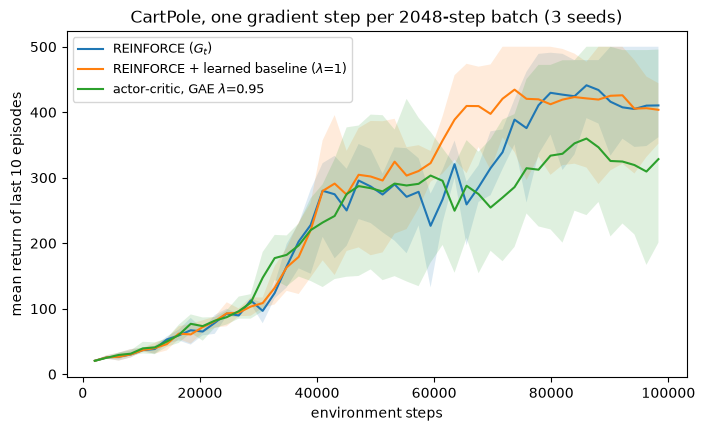

In [8]:
def collect_rollout(env, actor, n_steps, rng, carry):
    '''Run the current policy for n_steps (across episode boundaries). `carry` = (state, running_return, finished_returns).'''
    s, ep_ret, finished = carry
    buf = {k: [] for k in ["s", "a", "r", "s_next", "term", "end", "logp"]}
    for t in range(n_steps):
        p = softmax(actor.predict(s[None])[0])
        a = rng.choice(2, p=p)
        s_next, r, terminated, truncated = env.step(a)
        ep_ret += r
        for k, v in zip(buf, [s, a, r, s_next, float(terminated),
                              float(terminated or truncated or t == n_steps - 1), np.log(p[a])]):
            buf[k].append(v)
        if terminated or truncated:
            finished.append(ep_ret); ep_ret = 0.0; s = env.reset()
        else:
            s = s_next
    return {k: np.array(v) for k, v in buf.items()}, (s, ep_ret, finished)


def policy_logit_grad(logits, actions, adv, ent_coef):
    '''dLoss/dlogits for loss = -mean(adv * log pi(a|s)) - ent_coef * mean(entropy).'''
    p = softmax(logits)
    B = len(actions)
    d = -(adv[:, None] * (np.eye(p.shape[1])[actions] - p)) / B
    logp = np.log(p + 1e-12)
    H = -(p * logp).sum(axis=1, keepdims=True)
    d -= ent_coef * (-p * (logp + H)) / B
    return d


def train_pg(estimator="gae", total_steps=100_000, batch_steps=2048, lr=3e-3, critic_lr=3e-3,
             gamma=0.99, lam=0.95, ent_coef=0.0, seed=0):
    rng = np.random.default_rng(seed)
    env = CartPole(seed=seed)
    actor = MLP([4, 64, 64, 2], "tanh", out_scale=0.01, seed=seed)
    critic = MLP([4, 64, 64, 1], "tanh", seed=seed + 1000)
    a_opt, c_opt = Adam(actor.params, lr=lr), Adam(critic.params, lr=critic_lr)
    carry = (env.reset(), 0.0, [])
    log_steps, log_returns = [], []
    for it in range(total_steps // batch_steps):
        b, carry = collect_rollout(env, actor, batch_steps, rng, carry)
        if estimator == "reinforce":
            zeros = np.zeros(batch_steps)
            adv, _ = compute_gae(b["r"], zeros, zeros, b["term"], b["end"], gamma, lam=1.0)   # plain G_t
        else:
            V = critic.predict(b["s"])[:, 0]; V_next = critic.predict(b["s_next"])[:, 0]
            lam_used = 1.0 if estimator == "baseline" else lam
            adv, returns = compute_gae(b["r"], V, V_next, b["term"], b["end"], gamma, lam_used)
            out, cache = critic.forward(b["s"])
            c_opt.step(critic.backward(cache, (out[:, 0] - returns)[:, None] / batch_steps))
        logits, cache = actor.forward(b["s"])
        a_opt.step(actor.backward(cache, policy_logit_grad(logits, b["a"].astype(int), adv, ent_coef)))
        fin = carry[2]
        log_steps.append((it + 1) * batch_steps)
        log_returns.append(np.mean(fin[-10:]) if fin else 0.0)
    return np.array(log_steps), np.array(log_returns), actor, critic

results = {}
t0 = time.time()
for est in ["reinforce", "baseline", "gae"]:
    results[est] = [train_pg(estimator=est, seed=s) for s in range(3)]
print(f"trained 3 estimators x 3 seeds in {time.time() - t0:.0f}s")

labels = {"reinforce": "REINFORCE ($G_t$)", "baseline": "REINFORCE + learned baseline ($\\lambda$=1)",
          "gae": "actor-critic, GAE $\\lambda$=0.95"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for est, runs in results.items():
    steps = runs[0][0]; R = np.array([r[1] for r in runs])
    ax.plot(steps, R.mean(0), label=labels[est])
    ax.fill_between(steps, R.min(0), R.max(0), alpha=0.15)
ax.set_xlabel("environment steps"); ax.set_ylabel("mean return of last 10 episodes")
ax.set_title("CartPole, one gradient step per 2048-step batch (3 seeds)")
ax.legend(fontsize=9); plt.show()

All three learn. Perhaps surprisingly, the curves don't favor the fancier
estimators, and GAE even ends a bit lower here. Two honest reasons:

- CartPole is very forgiving (+1 every step, so $G_t$ is a well-behaved
  signal), and with 3 seeds the seed-to-seed noise is as big as the gap
  between methods.
- Our critic gets **one** gradient step per batch, so it's badly
  undertrained, and GAE *trusts* the critic ($\lambda < 1$ means bootstrapping
  from it). A wrong critic means biased advantages. PPO (notebook 6) trains
  the critic for many epochs per batch, which is part of why GAE shines there.

A learning curve is an indirect, noisy measurement. What baselines and GAE are supposed to
change is the **variance of the gradient estimate**, so let's measure that
directly. We freeze a partly-trained policy and critic, draw 30 independent
batches, compute the policy gradient under each estimator, and measure how
much the estimates disagree with each other. Lower means each gradient step is
more trustworthy.

In [9]:
def flat(grads):
    return np.concatenate([g[k].ravel() for g in grads for k in ("W", "b")])

_, _, actor_snap, critic_snap = train_pg(estimator="gae", total_steps=20_480, seed=7)
rng = np.random.default_rng(0)
env = CartPole(seed=11)
carry = (env.reset(), 0.0, [])
per_estimator = {"REINFORCE (G_t)": [], "baseline (lambda=1)": [], "GAE lambda=0.95": [], "TD error (lambda=0)": []}
for _ in range(30):
    b, carry = collect_rollout(env, actor_snap, 1024, rng, carry)
    V = critic_snap.predict(b["s"])[:, 0]; V_next = critic_snap.predict(b["s_next"])[:, 0]
    zeros = np.zeros_like(V)
    advs = {
        "REINFORCE (G_t)": compute_gae(b["r"], zeros, zeros, b["term"], b["end"], 0.99, 1.0)[0],
        "baseline (lambda=1)": compute_gae(b["r"], V, V_next, b["term"], b["end"], 0.99, 1.0)[0],
        "GAE lambda=0.95": compute_gae(b["r"], V, V_next, b["term"], b["end"], 0.99, 0.95)[0],
        "TD error (lambda=0)": compute_gae(b["r"], V, V_next, b["term"], b["end"], 0.99, 0.0)[0],
    }
    logits, cache = actor_snap.forward(b["s"])
    for name, adv in advs.items():
        per_estimator[name].append(flat(actor_snap.backward(cache, policy_logit_grad(logits, b["a"].astype(int), adv, 0.0))))

print(f"{'estimator':>22} | {'gradient variance (sum over params)':>36} | {'relative to REINFORCE':>21}")
base = None
for name, gs in per_estimator.items():
    var = np.array(gs).var(axis=0).sum()
    base = base or var
    print(f"{name:>22} | {var:>36.4f} | {var / base:>21.4f}")

             estimator |  gradient variance (sum over params) | relative to REINFORCE
       REINFORCE (G_t) |                               2.5256 |                1.0000
   baseline (lambda=1) |                               2.4220 |                0.9590
       GAE lambda=0.95 |                               0.4180 |                0.1655
   TD error (lambda=0) |                               0.0057 |                0.0022


This is the result the learning curves were hiding. The learned baseline on
its own ($\lambda = 1$) helps only a little here: the MC return sums hundreds of
random steps, and that noise dominates. The large win comes from
**bootstrapping**: GAE with $\lambda = 0.95$ cuts the variance several-fold, and
the pure TD error by orders of magnitude. The price, as always, is bias:
$\lambda = 0$ leans entirely on the critic, which is only partly trained. That's
why $\lambda \approx 0.95$ is the usual compromise, and why **PPO in notebook 6
uses exactly this GAE**.

## 8. The failure that motivates notebook 6: one step too far

Every method in this notebook takes **one** gradient step per batch and then
throws the batch away. Two problems follow.

**1. Sample inefficiency.** In LLM RL, generating the batch (running the model
autoregressively for thousands of tokens) is the expensive part. Using each
batch for a single small step is wasteful. The obvious fix — take many steps
on each batch — breaks the math: after the first step the data comes from an
*old* policy, and the policy gradient $\mathbb E_{\pi_\theta}[\cdot]$ is only valid for
data from the *current* one.

**2. Step size is uniquely dangerous in RL.** In supervised learning, a step
that's too big produces a bad model on the next batch, and the data is still
fine, so you recover. In RL **the policy generates its own data**. One bad step
that makes the policy (nearly) deterministic means the other actions are never
sampled again, so there's never a gradient telling the policy to try them. The
collapse can be **permanent**. Watch it happen on the bandit, where rewards are
all positive — a common situation, e.g. "fraction of unit tests passed":

In [10]:
def fraction_converged_to_best(lr, n_seeds=200, n_steps=300, shift=1.0):
    wins = 0
    for s in range(n_seeds):
        probs = bandit_pg(lr=lr, batch=4, n_steps=n_steps, baseline_kind="none", reward_shift=shift, seed=s)
        wins += np.argmax(probs[-1]) == 2
    return wins / n_seeds

for lr in [0.1, 1.0, 5.0, 20.0]:
    print(f"lr = {lr:5.1f}:  runs ending on the best arm = {100 * fraction_converged_to_best(lr):5.1f}%")

lr =   0.1:  runs ending on the best arm =  99.0%


lr =   1.0:  runs ending on the best arm =  85.5%


lr =   5.0:  runs ending on the best arm =  47.0%


lr =  20.0:  runs ending on the best arm =  34.0%


With a small learning rate almost every run finds the best arm. With a large
one, a big chunk of runs **lock onto whichever arm happened to get lucky early**
and never leave, because once $\pi \approx$ one-hot, the score
$\text{onehot}(a) - \pi \approx 0$ and learning stops. (The larger rates are
typically still stuck after 300 steps.)

The same thing happens with a neural-network policy on CartPole:

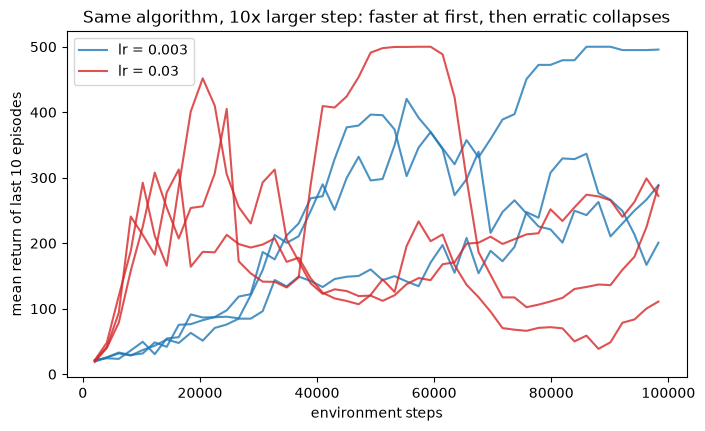

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for lr in [3e-3, 3e-2]:
    runs = [train_pg(estimator="gae", lr=lr, seed=s) for s in range(3)]
    for i, (steps, R, _, _) in enumerate(runs):
        ax.plot(steps, R, color="C0" if lr == 3e-3 else "C3", alpha=0.8,
                label=f"lr = {lr}" if i == 0 else None)
ax.set_xlabel("environment steps"); ax.set_ylabel("mean return of last 10 episodes")
ax.set_title("Same algorithm, 10x larger step: faster at first, then erratic collapses")
ax.legend(); plt.show()

The larger step learns *faster* at first, which is exactly why it's tempting,
then crashes: one run falls from 500 to about 100 within a few batches and
struggles to recover. The problem isn't the learning rate *per se*. A learning rate measures step size
in **parameter space**. What we actually care about is how much the **policy's
behavior** — its action distribution — changes. A step of size 0.01 in some
direction might barely change behavior. In another direction it might flip a
decision in every state. Notebook 6 fixes exactly this: measure the step in
distribution space (with the **KL divergence**), keep each update inside a
**trust region**, and use **importance sampling** to safely take many steps per
batch. The result is **PPO**.

## 9. What this means for LLMs

Everything in this notebook maps onto LLM training almost symbol for symbol:

| This notebook | LLM RL |
|---|---|
| bandit arm $a$ | a whole completion $y$ for prompt $x$ |
| $\log\pi_\theta(a)$ | $\log\pi_\theta(y\mid x) = \sum_t \log\pi_\theta(y_t \mid x, y_{<t})$ — sum of token log-probs |
| REINFORCE: $-\,r\cdot\log\pi_\theta(a)$ | "reward-weighted SFT on your own samples" |
| leave-one-out baseline over a batch | **RLOO** (notebook 8): $K$ completions per prompt, baseline = mean of the other $K-1$ |
| group mean / std baseline | **GRPO** (notebook 9) |
| per-token REINFORCE with $G_t$ | the MDP view, with reward at the last token |
| critic $V_\phi(s_t)$ + GAE | PPO's **value head** over each token prefix (notebooks 6–7) |
| "RL only improves where the policy goes" | why RL fine-tuning starts from a strong SFT model |
| policy collapse from one big step | mode collapse / degenerate text — prevented by trust regions and a KL penalty (notebook 6) |

Two special cases are worth naming because you'll meet them in the wild:

- **Rejection sampling fine-tuning** / "best-of-N then SFT": if the advantage
  is 1 for accepted samples and 0 for rejected ones, REINFORCE *is* SFT on the
  accepted samples. Many "self-improvement" pipelines are REINFORCE in disguise.
- **Sequence-level vs. token-level**: RLOO and GRPO give every token in a
  completion the *same* advantage (the bandit view). PPO gives each token its
  own GAE advantage from a learned critic (the MDP view). That's the
  notebook 1 distinction, now with gradients attached.

The production PyTorch version — a `Categorical` distribution, `log_prob`,
autograd instead of `policy_logit_grad`, and a CleanRL-style actor-critic on
gymnasium's CartPole — is in **notebook 10**.

## 10. Recap & exercises

**What we derived and built, from first principles:**

- The **log-derivative trick**, $\nabla\mathbb E_\pi[r] = \mathbb E_\pi[r\,\nabla\log\pi]$, checked
  numerically against the exact gradient, and the softmax score
  $\text{onehot}(a) - \pi$.
- Policy gradient as **reward-weighted supervised learning on the model's own
  samples**.
- **REINFORCE** for trajectories: the dynamics cancel (model-free), causality
  gives reward-to-go. Used to fine-tune a tiny token generator, and seen to
  improve only where the policy actually samples.
- **Baselines**: proved unbiased, variance reduction measured, and the
  **leave-one-out** baseline that becomes RLOO.
- **Actor-critic** and **GAE**: derived from n-step advantages via the
  telescoping TD-error identity, implemented with correct episode-boundary
  handling, and verified at $\lambda = 0$ and $\lambda = 1$.
- On CartPole, the **measured gradient variance** falling from REINFORCE →
  baseline → GAE → TD.
- Why one big step can collapse a policy **permanently**, motivating trust
  regions.

### Exercises

1. **Derive the exact bandit gradient.** Starting from
   $J = \sum_a \pi_a r_a$ with softmax $\pi$, show that
   $\partial J/\partial\theta_j = \pi_j(r_j - J)$. Notice it already has the form
   "probability × advantage."
2. **GRPO-style normalization.** In `bandit_pg`, add a baseline kind
   `"group"` that uses $(r_i - \text{mean}(r)) / (\text{std}(r) + 10^{-8})$ over the
   batch, *including* sample $i$. Measure its bias with `grad_variance`. (Hint:
   dividing by the std changes the gradient's *scale*, so compare directions,
   e.g. via cosine similarity to the exact gradient.)
3. **Entropy bonus.** Re-run the large-learning-rate bandit experiment with an
   entropy bonus on $\theta$ (you'll need its gradient — Section 7 has it). Does
   it rescue the runs that locked on to a bad arm?
4. **Sweep λ.** Train CartPole with GAE for $\lambda \in \{0, 0.5, 0.9, 0.95, 0.99, 1\}$
   and plot final performance. Where is the sweet spot, and why is it not at
   either end?
5. **Partial credit.** Change `TinySequenceEnv`'s reward to give 1/3 per
   correct token in the correct position (a "process reward," as in notebook
   1's exercise 4). How much faster does REINFORCE converge, and why? (Think
   about how often a batch has *zero* gradient.)